<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/Project_06/CNN_Cats_and_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 6 - Cats and Dogs Classification - CNN

## Problem Definition


This project focuses on a supervised binary classification problem in computer vision, specifically distinguishing between images of cats and dogs. A Convolutional Neural Network (CNN) is employed as the deep learning architecture to automatically extract relevant features and perform classification. The model undergoes training on labeled data and is subsequently evaluated on novel images to validate its predictive accuracy. This work exemplifies the efficacy of deep learning techniques in automating feature extraction and addressing traditionally challenging image recognition tasks.



## Data Collection


#####Importing Packages

In [1]:
#Importing packages for computing
import pandas as pd
import numpy as np

#For ploting graphs
import matplotlib.pyplot as plt

#Serializing / De-serializing objects
import pickle

#HTTP requests
import requests

#TTS - divides dataset for Training and Testing
from sklearn.model_selection import train_test_split

#Importing the Keras Model
from keras.models import Sequential
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D

from tensorflow.keras.utils import plot_model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

#importing OpenCV - for computer vision and image processing tasks
import cv2

#####Loading AWS files for computation

In [2]:
url_X = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'
url_y = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'
url_dog = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

{'url_X':url_X, 'url_y':url_y, 'url_dog':url_dog}

{'url_X': 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle',
 'url_y': 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle',
 'url_dog': 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'}

In [3]:
#Downloading  files from AWS
!curl -O {url_X}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  237M  100  237M    0     0  78.0M      0  0:00:03  0:00:03 --:--:-- 78.1M


In [4]:
!curl -O {url_y}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49948  100 49948    0     0   298k      0 --:--:-- --:--:-- --:--:--  297k


In [5]:
!curl -O {url_dog}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 60603  100 60603    0     0   408k      0 --:--:-- --:--:-- --:--:--  410k


#####Loading Pickled data

In [6]:
#HTTP GET request to AWS
response = requests.get(url_X)

#De-serialize the reponse from AWS
X = pickle.loads(response.content)

In [7]:
f"Shape of X: {X.shape}"

'Shape of X: (24946, 100, 100, 1)'

In [8]:
f"Number of images: {len(X)}"

'Number of images: 24946'

In [9]:
f"Dimensions of images: {X[0].shape}"

'Dimensions of images: (100, 100, 1)'

In [10]:
#HTTP GET request to AWS
response = requests.get(url_y)

#De-serialize the reponse from AWS
y = np.array(pd.read_pickle(url_y))

In [11]:
f"Shape of y: {y.shape}"

'Shape of y: (24946,)'

In [12]:
f"Number of images: {len(y)}"

'Number of images: 24946'

In [13]:
f"Number of classes: {len(np.unique(y))}"

'Number of classes: 2'

In [14]:
print(f"Class distribution:\n\t\tCats (0): {np.sum(y==0)},\n\t\tDogs (1): {np.sum(y==1)}")

Class distribution:
		Cats (0): 12470,
		Dogs (1): 12476


## Data Cleaning


In [15]:
#Normalizing pixel values 0-255 to 0-1 range
X = X / 255.0
X

array([[[[0.37254902],
         [0.36862745],
         [0.38431373],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.36078431],
         [0.35686275],
         [0.37254902],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.34901961],
         [0.35686275],
         [0.36078431],
         ...,
         [0.64705882],
         [0.6627451 ],
         [0.6627451 ]],

        ...,

        [[0.32941176],
         [0.29803922],
         [0.28627451],
         ...,
         [0.52941176],
         [0.64313725],
         [0.60392157]],

        [[0.32156863],
         [0.30980392],
         [0.27843137],
         ...,
         [0.55686275],
         [0.5254902 ],
         [0.6       ]],

        [[0.31372549],
         [0.33333333],
         [0.33333333],
         ...,
         [0.59215686],
         [0.57254902],
         [0.54117647]]],


       [[[0.67058824],
         [0.60392157],
         [0.54

## Exploratory Data Analysis


#####Shapes of the Data

In [16]:
#Shape of X - 4D
X.shape

(24946, 100, 100, 1)

In [17]:
f"Type of X: {type(X)}"

"Type of X: <class 'numpy.ndarray'>"

In [18]:
#Shape of y - 1D
y.shape

(24946,)

In [19]:
f"Type of X: {type(y)}"

"Type of X: <class 'numpy.ndarray'>"

#####Image Samples from Data

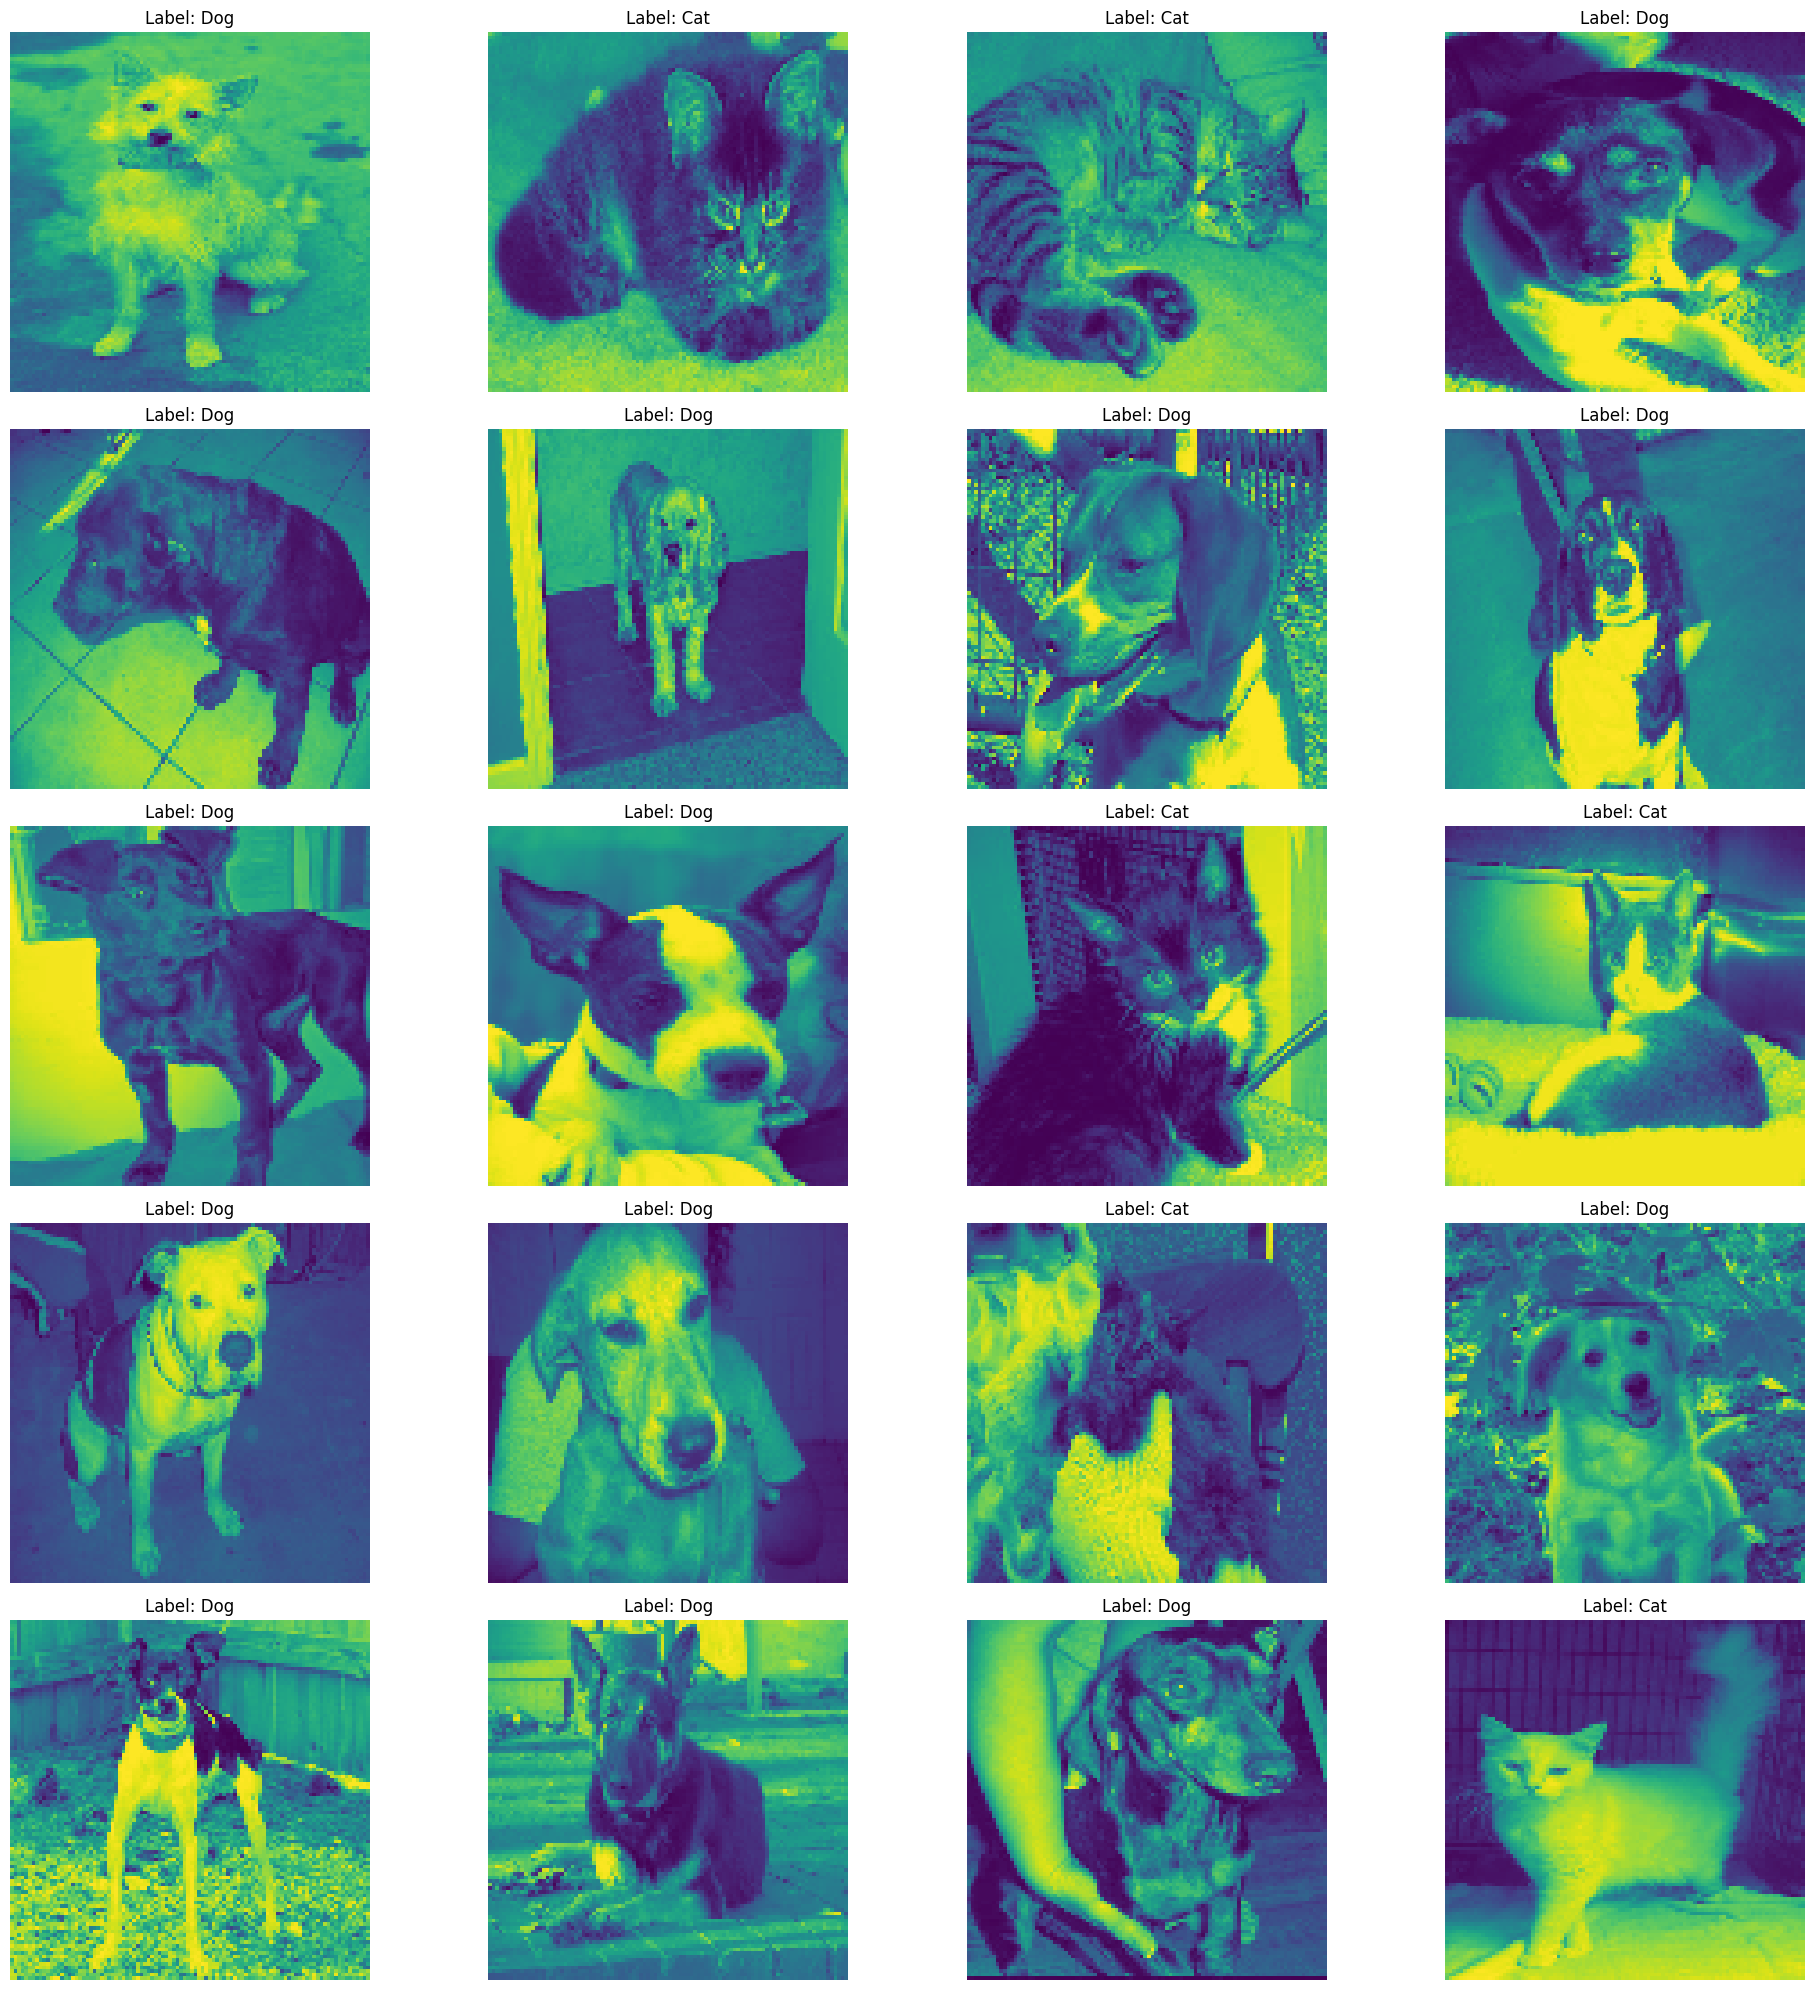

In [20]:
#Sample of 20 Images

fig, axes = plt.subplots(5, 4, figsize=(20,20))
axes = axes.ravel()

for i in range(20):
    axes[i].imshow(X[i])
    axes[i].set_title(f"Label: {'Dog' if y[i] == 0 else 'Cat'}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')

######Backing up data for test run

In [21]:
#Backup
X_sampling = X
y_sampling = y

In [22]:
#Restore
X = X_sampling
y = y_sampling

#####Setting Sample Data for test run

In [23]:
#Sampling with 10% of Data
sample_size = int(0.1 * len(X))
f'Selecting {sample_size} out of {len(X)}'

'Selecting 2494 out of 24946'

In [24]:
#Random indices from the sample size
random_index = np.random.choice(X.shape[0], size=sample_size, replace=False)
# random_index

In [25]:
#Sample Data
X = X[random_index]
y = y[random_index]

In [26]:
X.shape, y.shape

((2494, 100, 100, 1), (2494,))

## Data Processing


#####Train-Test-Split

In [27]:
#TTS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train.shape,y_train.shape,

((1995, 100, 100, 1), (1995,))

In [29]:
X_test.shape,y_test.shape,

((499, 100, 100, 1), (499,))

#####Building Model

In [30]:
model = Sequential()

In [31]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)

In [32]:
# Define first hidden layers
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [33]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)

In [34]:
# Define third hidden layer
model.add(
  Conv2D(
    name = "Conv3",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)

In [35]:
# Flatten input data into a 1D structure
model.add(
    Flatten()
)

In [36]:
# Define output layer
model.add(
  Dense(
    name = "output",
    units = 1,
    activation = 'sigmoid' ,
  )
)

#####Model Compilation

In [37]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)

#####Model Fitment

In [44]:
# Fit model
fitment = model.fit(
    X_train
    , y_train
    , epochs=12
    , batch_size=32
    , validation_data=(
        X_test
        , y_test
      )
);

Epoch 1/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 1.0550e-04 - val_accuracy: 0.7154 - val_loss: 2.4352
Epoch 2/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 1.2013e-04 - val_accuracy: 0.7134 - val_loss: 2.4666
Epoch 3/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 1.0564e-04 - val_accuracy: 0.7154 - val_loss: 2.4600
Epoch 4/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 9.8955e-05 - val_accuracy: 0.7114 - val_loss: 2.4867
Epoch 5/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 1.0326e-04 - val_accuracy: 0.7154 - val_loss: 2.4849
Epoch 6/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 8.8191e-05 - val_accuracy: 0.7154 - val_loss: 2.5089
Epoch 7/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 8.6953e-05 - val_accuracy: 0.7194 - val_loss: 2.5169
Epoch 8/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 7.554

#####Model Summary

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,693 (948.02 KB)

 Trainable params: 80,897 (316.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 161,796 (632.02 KB)

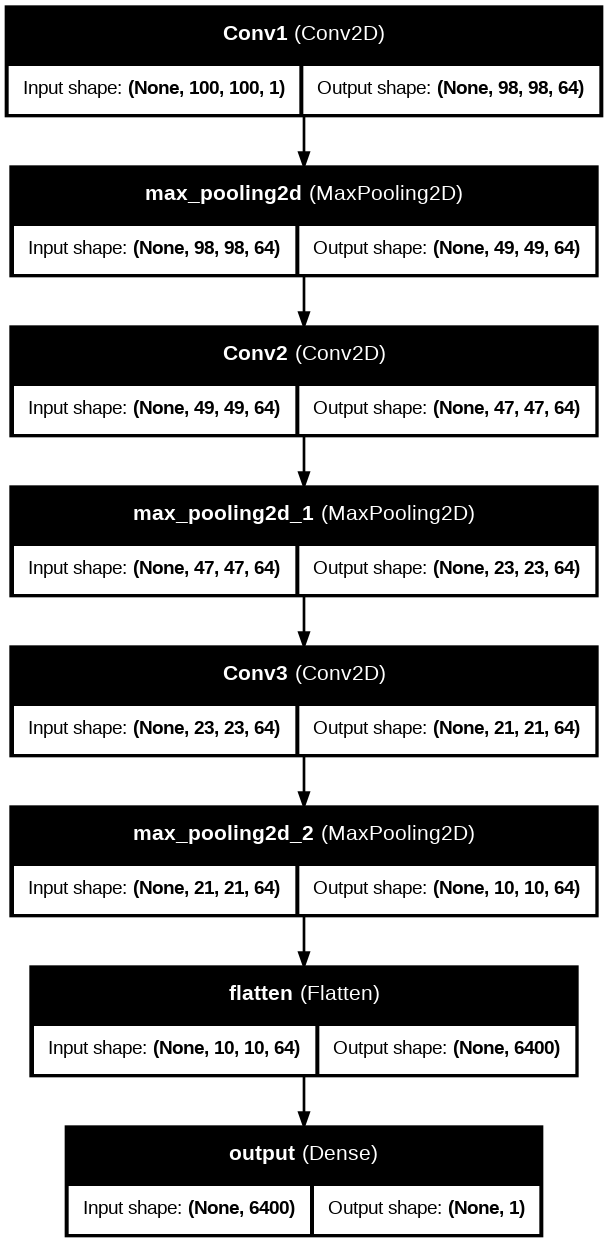

In [46]:
plot_model(model,
           to_file='model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',  # TB = top to bottom, LR = left to right
           expand_nested=True,
           dpi=96)

#####Model Evaluation

In [47]:
# Evaluate the model on the validation set (X_test and y_test)
val_loss, val_accuracy = model.evaluate(X_test, y_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7352 - loss: 2.5193


In [48]:
# Output the evaluation results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

Validation Accuracy: 0.7134
Validation Loss: 2.5841


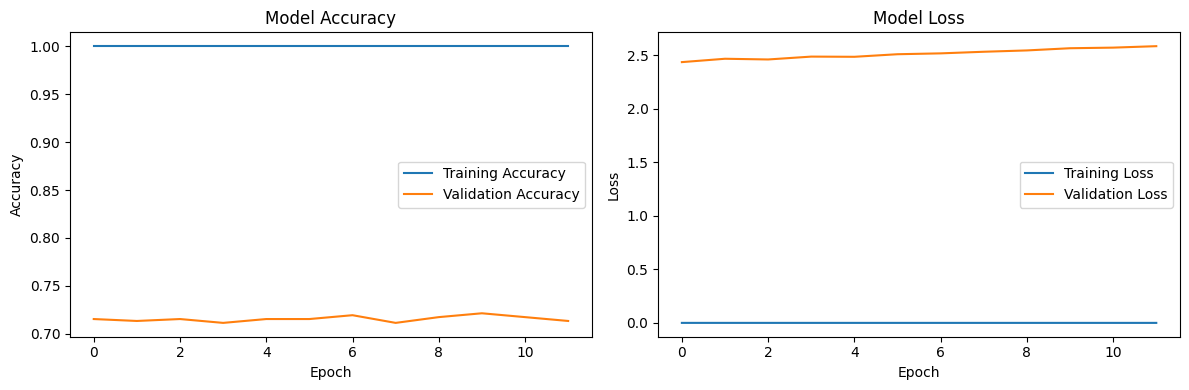

In [49]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fitment.history['accuracy'], label='Training Accuracy')
plt.plot(fitment.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(fitment.history['loss'], label='Training Loss')
plt.plot(fitment.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

#####Distribution of Probabilities

In [50]:
#Predictions of the Test set
predictions = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [51]:
# Flatten the predictions array to make it 1D
probabilities = predictions.flatten()

In [52]:
# Threshold to bifurcate the 2 probabilities
threshold = 0.5

In [53]:
#Probabilities are 2 - greater than equal to threshold or less than threshold
probability_0 = probabilities[probabilities < threshold]
probability_1 = probabilities[probabilities >= threshold]

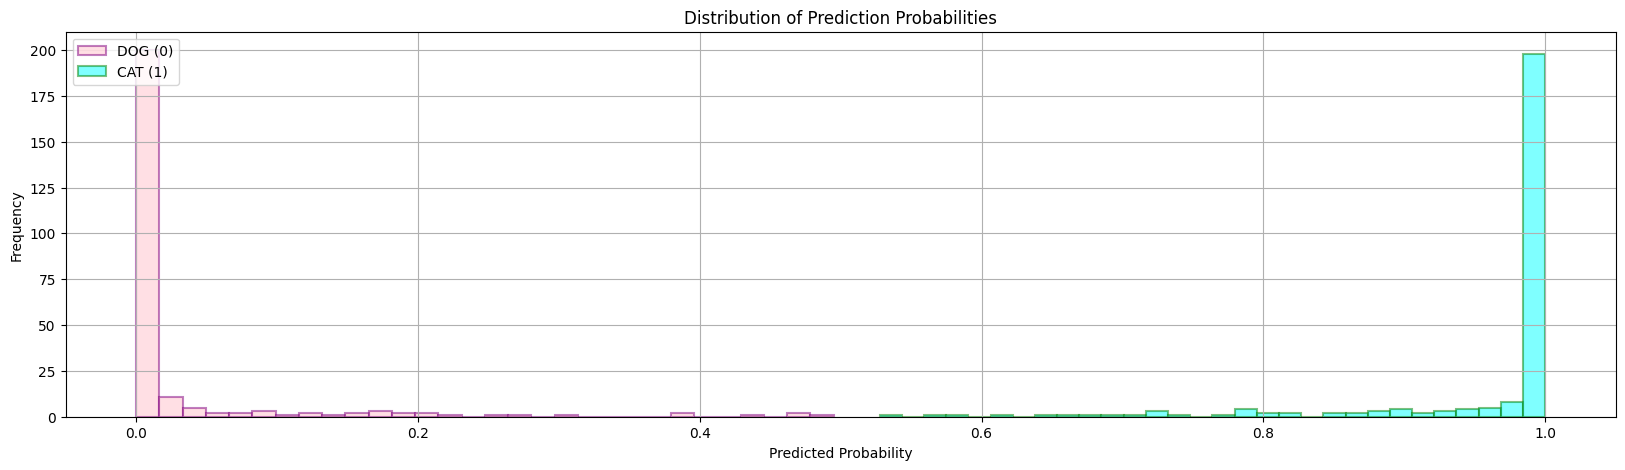

In [54]:
#Plotting the Probabilities
plt.figure(figsize=(20, 5))

#Probability 0
plt.hist(probability_0, label='DOG (0)', bins=30, color='pink', edgecolor='purple', alpha=0.5, linewidth=1.5)

#Probability 1
plt.hist(probability_1, label='CAT (1)', bins=30, color='cyan', edgecolor='green', alpha=0.5, linewidth=1.5)

plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.grid(True)

In [55]:
model.input_shape

(None, 100, 100, 1)

#####Function to Resize Image

In [63]:
def img_resize(imag='sozo.jpg', color=''):

  img = cv2.imread(imag)

  target_size  = (100,100)

  resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
  grayscale_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
  img_reshape = grayscale_img.reshape(1,100,100,1)

  if(color.lower()=='gray'):
    plt.imshow(img_reshape[0,:],cmap=plt.cm.gray)
  elif(color.lower()=='gray reverse'):
    plt.imshow(img_reshape[0,:],cmap=plt.cm.gray_r)
  elif(color.lower()==''):
    plt.imshow(img_reshape[0,:],)
  else:
    print("Choice of Color scheme is invalid")

  plt.axis('Off')
  plt.title(imag)

  image_array = img_reshape / 255.0
  image_array = image_array.reshape((1, 100, 100, 1))

  # Use the model to make a prediction
  prediction = model.predict(image_array)

  # Interpret the prediction
  if prediction[0][0] < 0.5:
      label_img = "Dog"
  else:
      label_img = "Cat"

  plt.title(f"Predicted: {label_img} (Probability: {prediction[0][0]:.4f})")

  # Output the prediction for verification
  print(f"Prediction probability: {prediction[0][0]:.4f}")
  print(f"The image is predicted to be a {label_img}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction probability: 0.9993
The image is predicted to be a Cat


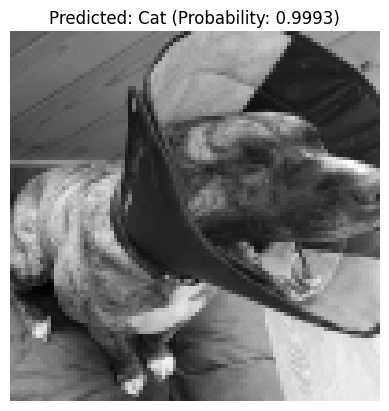

In [64]:
img_resize('dog.jpg','gray')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction probability: 0.9993
The image is predicted to be a Cat


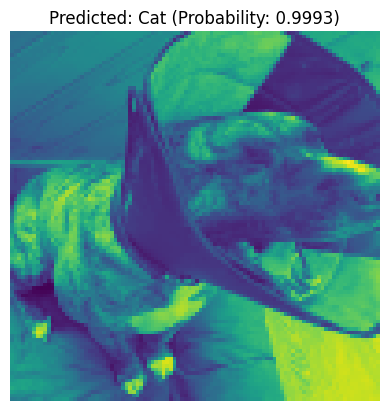

In [65]:
img_resize('dog.jpg')

## Communication of Results


###Quantitative Results

- Training Accuracy:    ~100% (converged after 12 epochs)
- Validation Accuracy:  ~69-71%
- Training Loss:        Decreased from 0.3 to nearly 0
- Validation Loss:      Increased from 0.75 to 1.4

The model shows strong learning capability on training data to ~100% but the validation accuracy leveled to ~70%, indicating a major gap between the training and testing performance.

###Model Overview

The implemented CNN consists of:
- Three convolutional blocks (64 filters each, 3×3 kernel)
- MaxPooling layers (2×2) after each convolution for spatial dimension reduction
- Flatten layer for converting 2D features to 1D
- Single output neuron with sigmoid activation for binary classification
- Total parameters:
    - Total params: 242,693 (948.02 KB)
    - Trainable params: 80,897 (316.00 KB)
    - Non-trainable params: 0 (0.00 B)
    - Optimizer params: 161,796 (632.02 KB)

This model enables hierarchical feature extraction, progressing from
low-level features to high-level representations.

###Training Observations

- Training accuracy reached 100% while validation accuracy remained at 70%, indicating the model memorized training examples rather than learning generalizable patterns.
- The validation loss increased from 0.75 to 1.4 over 12 epochs, suggesting the model's predictions became less confident and less accurate on unseen data as training progressed.
- Training metrics stabilized around epoch 8-10, while validation metrics showed no improvement, suggesting further training provided no benefit to generalization.
- The model performs exceptionally on training data but struggles to generalize to new images, limiting its real-world applicability.



###Prediction Distribution

- Clear bimodal distribution with distinct peaks near 0 (Dog) and 1 (Cat)
- Model demonstrates decisive predictions rather than uncertain classifications
- Most predictions fall confidently into one category or the other
- Few predictions near the 0.5 threshold indicate the model rarely expresses uncertainty

###Deployment and Testing

- Used the rained model to classify a new/unfamiliar image
  - Resized to 100x100 pixels
  - Converted it to gray scale
  - Normalized it
- Achieved real-time prediction capability on individual images
- Output includes both classification label and probability score
  - For dog.jpg
    - Classified as Cat
    - Prediction Probability: 99.93%
  - For sozo.jpg
    - Classified as Dog
    - Prediction Probability: 0.00%
     


###Limitations

- Overfitting - 30% gap between training and validation accuracy.
- Data Restricted - use of only 10% of the available data may have limited the potential.
- Validation - With 70% accuracy, model performs moderately.

###Recommendations for Improvement

- Increase the data for more training and testing.
- Using Regularization techniques.
- Cross-validation for more robust performance estimates.

## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.

**`NOTE: Uncomment the below code once sozo.jpg is uploaded for testing`**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction probability: 0.0000
The image is predicted to be a Dog


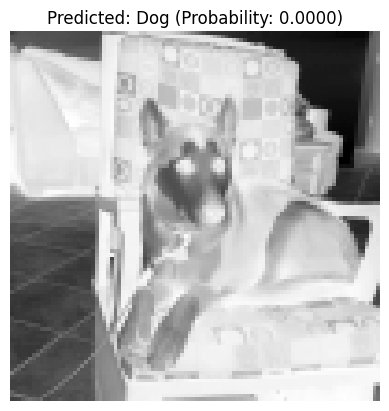

In [66]:
#img_resize('sozo.jpg','Gray Reverse')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction probability: 0.0000
The image is predicted to be a Dog


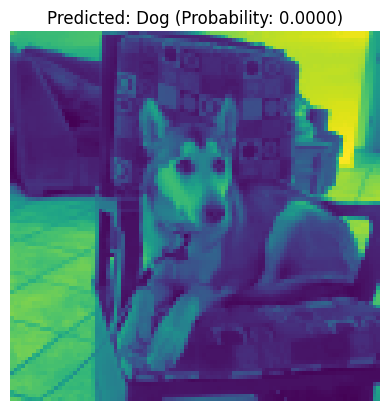

In [67]:
#img_resize('sozo.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction probability: 0.0000
The image is predicted to be a Dog


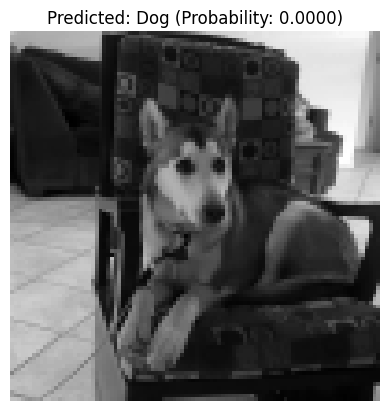

In [68]:
#img_resize('sozo.jpg','Gray')